# Global Tropical Cyclone Exposure Data — 2017

Visualization of storm-level wind exposure from the [sparklabnyc/global_tc_2024](https://github.com/sparklabnyc/global_tc_2024) pipeline.  
Dataset: `global_storm_winds_2017.rds` — 3.65M rows × 11 columns mapping ADM2 regions to TC wind fields.

In [1]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})

# Load data
df = pyreadr.read_r("../exposure_data/global_storm_winds_2017.rds")[None]
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (3651826, 11)
Columns: ['ADM2_id', 'date_time_max_wind', 'vmax_sust', 'vmax_gust', 'sust_dur', 'gust_dur', 'sid', 'storm_id', 'usa_atcf_id', 'closest_date', 'storm_dist']


,ADM2_id,date_time_max_wind,vmax_sust,vmax_gust,sust_dur,gust_dur,sid,storm_id,usa_atcf_id,closest_date,storm_dist
0,17698898B67359070524975,NaT,0.0,0.0,0.0,0.0,2017061S11063,Enawo-2017,SH092017,2017-03-02 06:00:00,5146.616010
1,17698898B98443198567384,NaT,0.0,0.0,0.0,0.0,2017061S11063,Enawo-2017,SH092017,2017-03-02 06:00:00,5142.051813
2,17698898B82675281335003,NaT,0.0,0.0,0.0,0.0,2017061S11063,Enawo-2017,SH092017,2017-03-02 06:00:00,5159.863711
3,17698898B74585757664988,NaT,0.0,0.0,0.0,0.0,2017061S11063,Enawo-2017,SH092017,2017-03-02 06:00:00,5165.933422
4,17698898B84066352785355,NaT,0.0,0.0,0.0,0.0,2017061S11063,Enawo-2017,SH092017,2017-03-02 06:00:00,5123.345646


## 1. Overview Statistics

In [2]:
exposed = df[df["vmax_sust"] > 0].copy()

print(f"Total rows:                {len(df):,}")
print(f"Rows with wind exposure:   {len(exposed):,} ({100*len(exposed)/len(df):.1f}%)")
print(f"Unique storms (sid):       {df['sid'].nunique()}")
print(f"Unique ADM2 regions:       {df['ADM2_id'].nunique()}")
print(f"ADM2 regions exposed:      {exposed['ADM2_id'].nunique()}")
print(f"Max sustained wind:        {df['vmax_sust'].max():.1f} m/s")
print(f"Max gust wind:             {df['vmax_gust'].max():.1f} m/s")

Total rows:                3,651,826
Rows with wind exposure:   345,771 (9.5%)
Unique storms (sid):       74


Unique ADM2 regions:       49349


ADM2 regions exposed:      34825
Max sustained wind:        64.6 m/s
Max gust wind:             96.2 m/s


## 2. Distribution of Maximum Sustained Wind Speeds

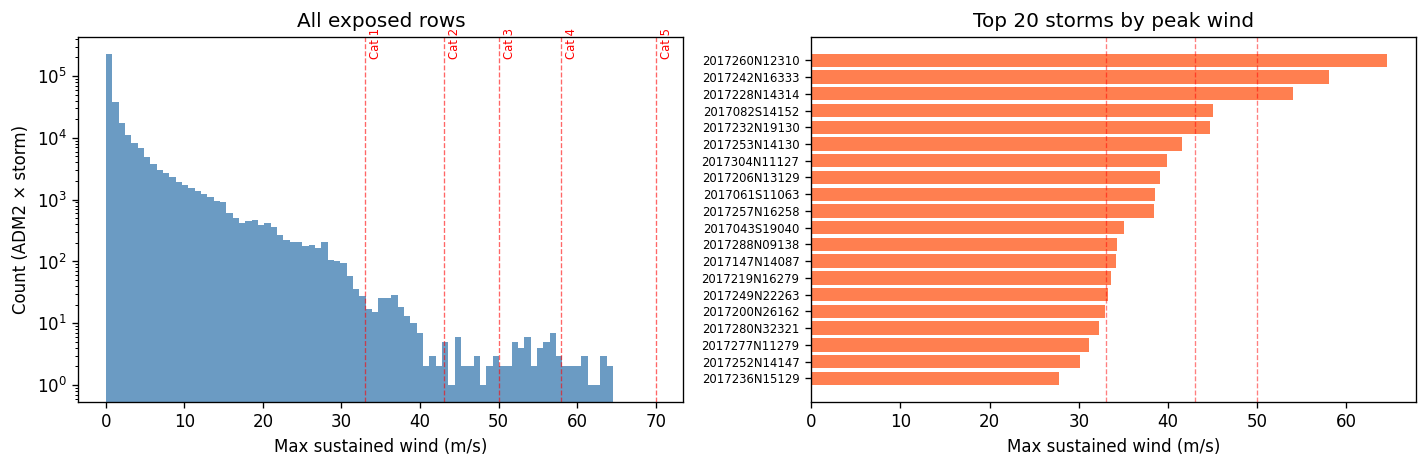

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# All exposed rows
axes[0].hist(exposed["vmax_sust"], bins=80, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].set_xlabel("Max sustained wind (m/s)")
axes[0].set_ylabel("Count (ADM2 × storm)")
axes[0].set_title("All exposed rows")
axes[0].set_yscale("log")

# Saffir-Simpson thresholds (m/s): Cat 1=33, Cat 2=43, Cat 3=50, Cat 4=58, Cat 5=70
thresholds = [33, 43, 50, 58, 70]
labels = ["Cat 1", "Cat 2", "Cat 3", "Cat 4", "Cat 5"]
for t, lbl in zip(thresholds, labels):
    axes[0].axvline(t, color="red", ls="--", lw=0.8, alpha=0.6)
    axes[0].text(t + 0.5, axes[0].get_ylim()[1] * 0.5, lbl, fontsize=7, color="red", rotation=90)

# Per-storm max wind
storm_max = df.groupby("sid")["vmax_sust"].max().sort_values(ascending=False)
axes[1].barh(range(len(storm_max[:20])), storm_max[:20].values, color="coral", edgecolor="none")
axes[1].set_yticks(range(len(storm_max[:20])))
axes[1].set_yticklabels(storm_max[:20].index, fontsize=7)
axes[1].set_xlabel("Max sustained wind (m/s)")
axes[1].set_title("Top 20 storms by peak wind")
axes[1].invert_yaxis()
for t in thresholds[:3]:
    axes[1].axvline(t, color="red", ls="--", lw=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Temporal Distribution of Storms in 2017

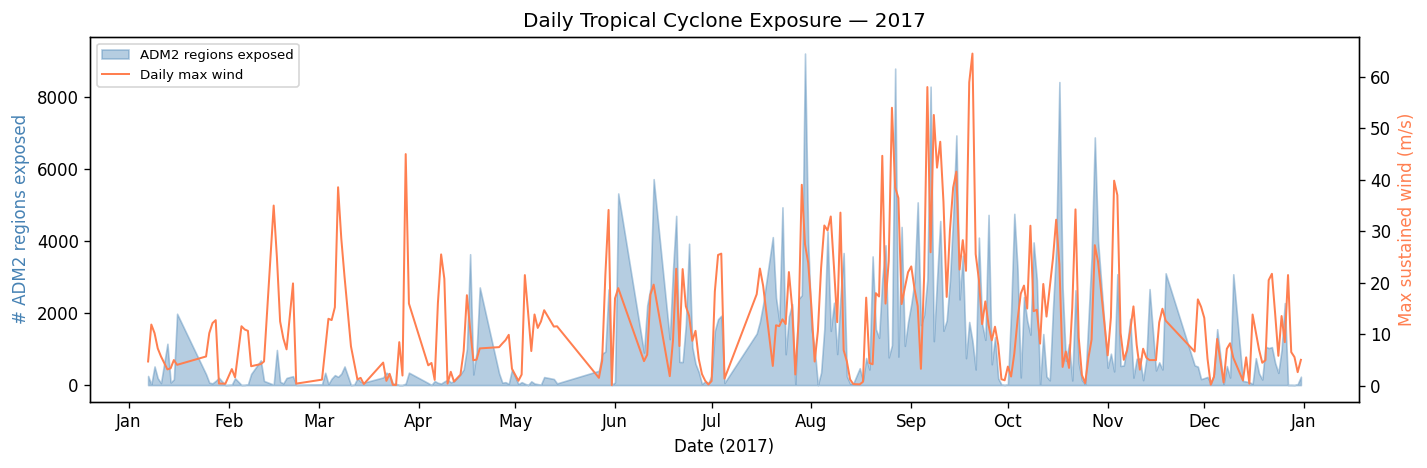

In [4]:
# Timeline: number of ADM2 regions exposed per day
exposed["date"] = exposed["closest_date"].dt.date
daily = exposed.groupby("date").agg(
    n_regions=("ADM2_id", "nunique"),
    mean_wind=("vmax_sust", "mean"),
    max_wind=("vmax_sust", "max"),
).reset_index()
daily["date"] = pd.to_datetime(daily["date"])

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.fill_between(daily["date"], daily["n_regions"], color="steelblue", alpha=0.4, label="ADM2 regions exposed")
ax1.set_ylabel("# ADM2 regions exposed", color="steelblue")
ax1.set_xlabel("Date (2017)")

ax2 = ax1.twinx()
ax2.plot(daily["date"], daily["max_wind"], color="coral", lw=1.2, label="Daily max wind")
ax2.set_ylabel("Max sustained wind (m/s)", color="coral")

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.set_title("Daily Tropical Cyclone Exposure — 2017")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 4. Exposure Duration Distribution

ADM2-storm pairs with sust_dur > 0: 3,196


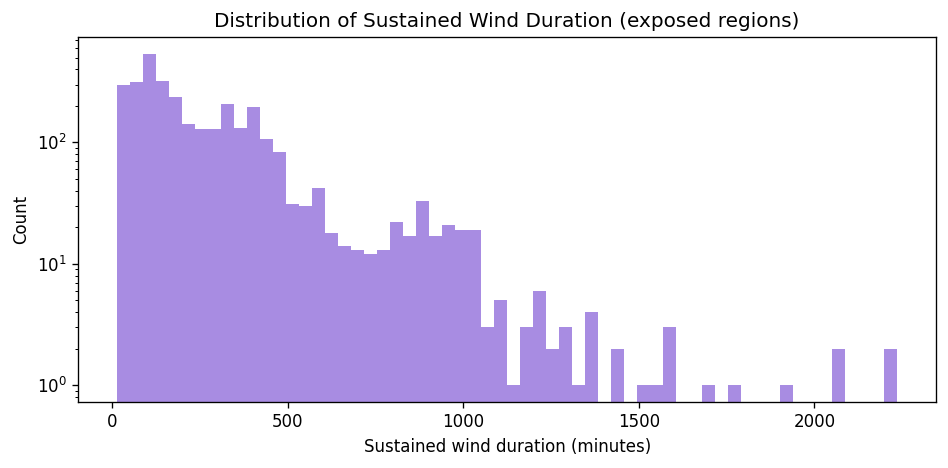

In [5]:
# Duration of sustained wind exposure per ADM2-storm pair
dur = exposed[exposed["sust_dur"] > 0]["sust_dur"]
print(f"ADM2-storm pairs with sust_dur > 0: {len(dur):,}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dur, bins=60, color="mediumpurple", edgecolor="none", alpha=0.8)
ax.set_xlabel("Sustained wind duration (minutes)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Sustained Wind Duration (exposed regions)")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

## 5. Storm Distance vs. Wind Speed

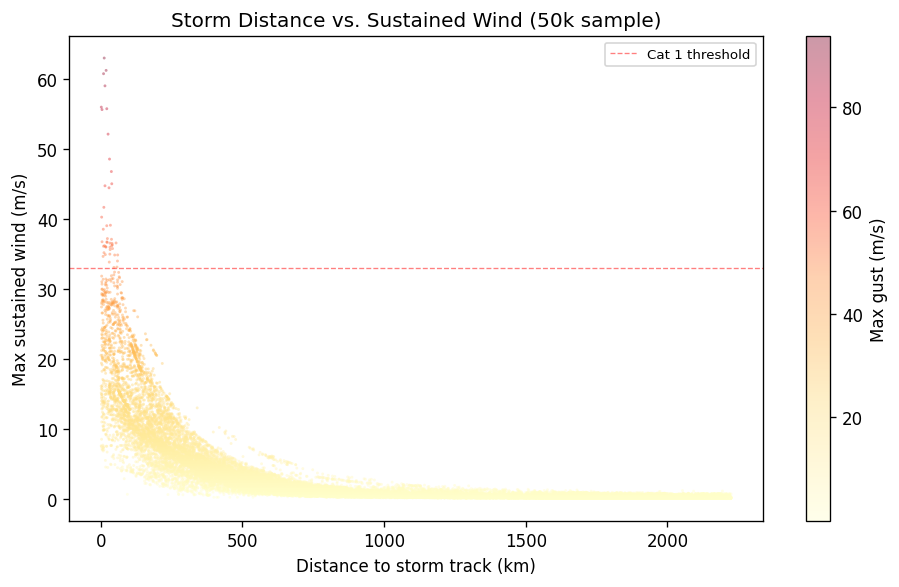

In [6]:
# Sample for scatter (full data is 3.6M rows)
sample = exposed.sample(n=min(50_000, len(exposed)), random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    sample["storm_dist"],
    sample["vmax_sust"],
    c=sample["vmax_gust"],
    cmap="YlOrRd",
    s=3,
    alpha=0.4,
    edgecolors="none",
)
plt.colorbar(sc, label="Max gust (m/s)")
ax.set_xlabel("Distance to storm track (km)")
ax.set_ylabel("Max sustained wind (m/s)")
ax.set_title("Storm Distance vs. Sustained Wind (50k sample)")
ax.axhline(33, color="red", ls="--", lw=0.8, alpha=0.5, label="Cat 1 threshold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Number of ADM2 Regions Exposed per Storm

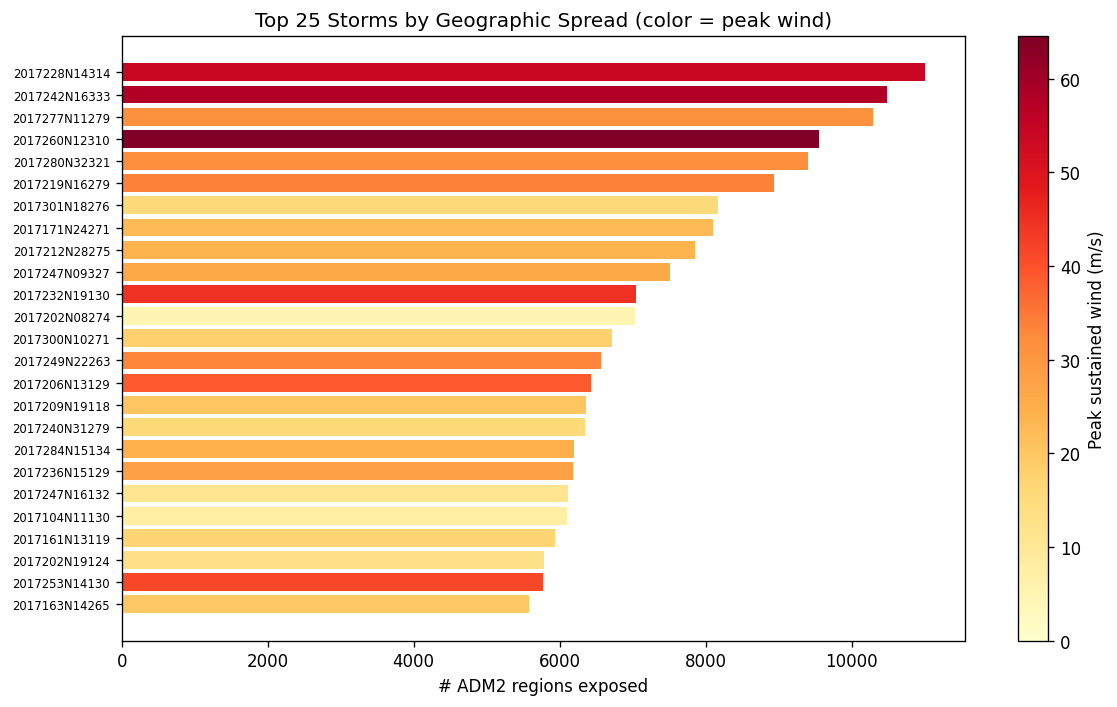

In [7]:
storm_stats = exposed.groupby("sid").agg(
    n_regions=("ADM2_id", "nunique"),
    max_wind=("vmax_sust", "max"),
    mean_wind=("vmax_sust", "mean"),
).sort_values("n_regions", ascending=False)

top = storm_stats.head(25)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(top)), top["n_regions"], color=plt.cm.YlOrRd(top["max_wind"] / top["max_wind"].max()), edgecolor="none")
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=7)
ax.set_xlabel("# ADM2 regions exposed")
ax.set_title("Top 25 Storms by Geographic Spread (color = peak wind)")
ax.invert_yaxis()

# Add colorbar
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(0, top["max_wind"].max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Peak sustained wind (m/s)")

plt.tight_layout()
plt.show()

## 7. Monthly Storm Activity

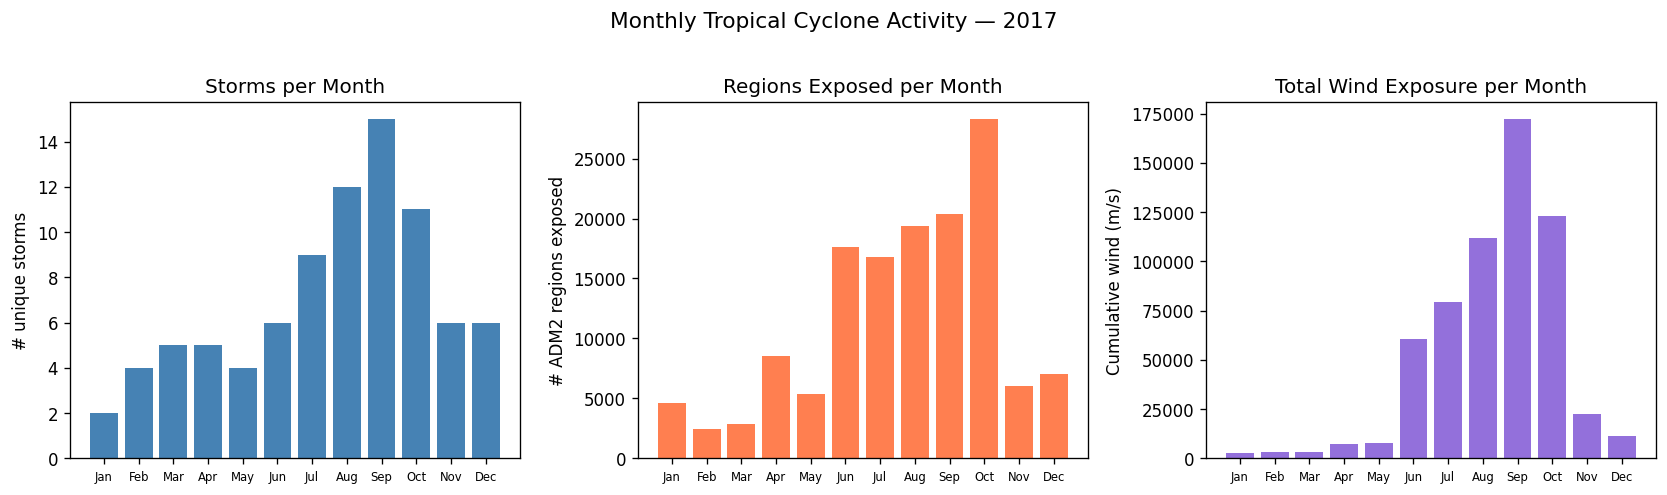

In [8]:
exposed["month"] = exposed["closest_date"].dt.month

monthly = exposed.groupby("month").agg(
    n_storms=("sid", "nunique"),
    n_regions=("ADM2_id", "nunique"),
    total_exposure=("vmax_sust", "sum"),
).reset_index()

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(monthly["month"], monthly["n_storms"], color="steelblue")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names, fontsize=7)
axes[0].set_ylabel("# unique storms")
axes[0].set_title("Storms per Month")

axes[1].bar(monthly["month"], monthly["n_regions"], color="coral")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names, fontsize=7)
axes[1].set_ylabel("# ADM2 regions exposed")
axes[1].set_title("Regions Exposed per Month")

axes[2].bar(monthly["month"], monthly["total_exposure"], color="mediumpurple")
axes[2].set_xticks(range(1, 13))
axes[2].set_xticklabels(month_names, fontsize=7)
axes[2].set_ylabel("Cumulative wind (m/s)")
axes[2].set_title("Total Wind Exposure per Month")

plt.suptitle("Monthly Tropical Cyclone Activity — 2017", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Gust vs. Sustained Wind Relationship

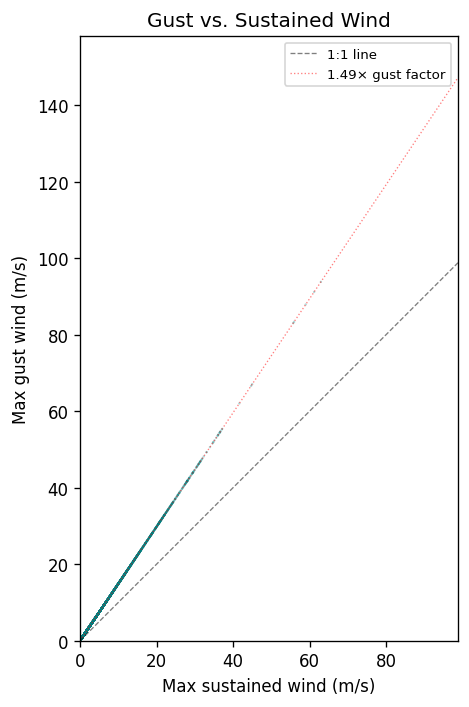

In [9]:
both = exposed[(exposed["vmax_gust"] > 0)].sample(n=30_000, random_state=42)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(both["vmax_sust"], both["vmax_gust"], s=2, alpha=0.3, color="teal", edgecolors="none")
lim = max(both["vmax_sust"].max(), both["vmax_gust"].max()) + 5
ax.plot([0, lim], [0, lim], "k--", lw=0.8, alpha=0.5, label="1:1 line")
ax.plot([0, lim], [0, lim * 1.49], color="red", ls=":", lw=0.8, alpha=0.5, label="1.49× gust factor")
ax.set_xlabel("Max sustained wind (m/s)")
ax.set_ylabel("Max gust wind (m/s)")
ax.set_title("Gust vs. Sustained Wind")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim * 1.6)
ax.legend(fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()